In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak
from pathlib import Path
import pickle
import os
import dask.dataframe as dd

import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)
from torch.utils.data import Dataset, DataLoader

import torch.nn as nn
import torch.nn.functional as F

2.10.0
0.22.1


In [2]:
# Caricamento dati

file_path_z = "data/ZJetsToQQ_13TeV-madgraphMLM-pythia8-NEVENT10000-RS54000001.parquet"
file_path_w = "data/WJetsToQQ_13TeV-madgraphMLM-pythia8-NEVENT10000-RS45000001.parquet"
parameters = [
    # Jets
    "FullReco_JetAK4_PT",
    "FullReco_JetAK4_Eta",
    "FullReco_JetAK4_Phi",
    "FullReco_JetAK4_Mass",
    "FullReco_JetAK4_Charge",
    "FullReco_JetAK4_Constituents",

    #Contituents
    "FullReco_PFCand_PT",
    "FullReco_PFCand_Eta",
    "FullReco_PFCand_Phi",
    "FullReco_PFCand_PID",
    "FullReco_PFCand_Charge",
    "FullReco_PFCand_Mass",
    "FullReco_PFCand_D0",
    "FullReco_PFCand_DZ",
    "FullReco_PFCand_ErrorD0",
    "FullReco_PFCand_ErrorDZ",
    "FullReco_PFCand_fUniqueID",
    "FullReco_PFCand_PuppiW"
]

ddf_z = dd.read_parquet(file_path_z, parameters)
ddf_w = dd.read_parquet(file_path_w, parameters)

In [3]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import dask.dataframe as dd
import warnings
warnings.filterwarnings('ignore')

# Parametri essenziali per costituente (14 features totali)
CONSTITUENT_FEATURES = [
    'log1p_pt',         # 0: log(1+pt)
    'delta_eta',        # 1: η - η_jet
    'delta_phi',        # 2: φ - φ_jet (periodico)
    'charge',           # 3: carica
    'log1p_mass',       # 4: log(1+ massa)
    'd0_norm',          # 5: d0/σ_d0
    'dz_norm',          # 6: dz/σ_dz
    'log1p_d0_err',     # 7: log(1+σ_d0)
    'log1p_dz_err',     # 8: log(1+σ_dz)
    'puppiW',           # 9: peso pileup
    'is_charged',       # 10: 1 se carica ≠ 0
    'is_pion',          # 11: 1 se |PID| == 45
    'is_kaon',          # 12: 1 se |PID| == 65
    'is_proton',        # 13: 1 se |PID| == 92
]

# PID da escludere
EXCLUDE_PID = {22}  # fotoni

def safe_log1p(x):
    """log(1+x) - sempre positivo, stabile per x=0"""
    return np.log1p(max(abs(x), 0))

def prepare_jet_dataset(ddf, min_jet_pt=50, max_constituents=60, min_constituents=3, n_partitions=None):
    """
    Prepara dataset jet+constituents per foundation model.
    """
    def process_partition(partition):
        examples = []
        
        for _, row in partition.iterrows():
            # --- Estrazione dati con fallback safe ---
            def safe_arr(key, default=np.array([])):
                val = row.get(key)
                if val is None:
                    return default
                return np.asarray(val).flatten()
            
            jet_pt = safe_arr('FullReco_JetAK4_PT')
            jet_eta = safe_arr('FullReco_JetAK4_Eta')
            jet_phi = safe_arr('FullReco_JetAK4_Phi')
            jet_mass = safe_arr('FullReco_JetAK4_Mass')
            jet_charge = safe_arr('FullReco_JetAK4_Charge', np.zeros_like(jet_pt))  # aggiunto
            jet_constituents = row.get('FullReco_JetAK4_Constituents', [])
            
            pf_pt = safe_arr('FullReco_PFCand_PT')
            pf_eta = safe_arr('FullReco_PFCand_Eta')
            pf_phi = safe_arr('FullReco_PFCand_Phi')
            pf_mass = safe_arr('FullReco_PFCand_Mass')
            pf_charge = safe_arr('FullReco_PFCand_Charge')
            pf_pid = safe_arr('FullReco_PFCand_PID')
            pf_d0 = safe_arr('FullReco_PFCand_D0')
            pf_dz = safe_arr('FullReco_PFCand_DZ')
            pf_d0_err = safe_arr('FullReco_PFCand_ErrorD0', np.ones_like(pf_pt))
            pf_dz_err = safe_arr('FullReco_PFCand_ErrorDZ', np.ones_like(pf_pt))
            pf_puppi = safe_arr('FullReco_PFCand_PuppiW', np.ones_like(pf_pt))
            pf_id = safe_arr('FullReco_PFCand_fUniqueID')
            
            if len(jet_pt) == 0 or len(pf_pt) == 0:
                continue
            
            # Mappa ID -> indice
            id_to_idx = {int(id_val): i for i, id_val in enumerate(pf_id) if id_val is not None}
            
            # Processa ogni jet
            for j in range(len(jet_pt)):
                # Tagli base
                if jet_pt[j] < min_jet_pt or jet_mass[j] <= 0:
                    continue
                
                if j >= len(jet_constituents):
                    continue
                
                # Ottieni IDs dei costituenti
                const_ids = jet_constituents[j]
                if const_ids is None:
                    continue
                const_ids = np.atleast_1d(const_ids).flatten()
                
                # Estrai features costituenti
                features = []
                for cid in const_ids:
                    try:
                        idx = id_to_idx.get(int(cid))
                        if idx is None or idx >= len(pf_pid):
                            continue
                        
                        pid = abs(int(pf_pid[idx]))
                        if pid in EXCLUDE_PID:
                            continue
                        
                        # Calcola features con safe_log1p
                        log1p_pt = safe_log1p(pf_pt[idx])
                        delta_eta = pf_eta[idx] - jet_eta[j]
                        delta_phi = ((pf_phi[idx] - jet_phi[j] + np.pi) % (2*np.pi)) - np.pi
                        log1p_mass = safe_log1p(pf_mass[idx])
                        
                        d0_norm = pf_d0[idx] #/ max(pf_d0_err[idx], 1e-8)      momentaneamente no normalizzazione con errore
                        dz_norm = pf_dz[idx] #/ max(pf_dz_err[idx], 1e-8)
                        log1p_d0_err = safe_log1p(pf_d0_err[idx])
                        log1p_dz_err = safe_log1p(pf_dz_err[idx])
                        
                        features.append([
                            log1p_pt, delta_eta, delta_phi,
                            pf_charge[idx], log1p_mass,
                            d0_norm, dz_norm,
                            log1p_d0_err, log1p_dz_err,
                            pf_puppi[idx],
                            1.0 if pf_charge[idx] != 0 else 0.0,
                            1.0 if pid == 45 else 0.0,
                            1.0 if pid == 65 else 0.0,
                            1.0 if pid == 92 else 0.0,
                        ])
                    except (ValueError, TypeError, IndexError):
                        continue
                
                if len(features) < min_constituents:
                    continue
                
                # Padding/truncation
                features = np.array(features[:max_constituents], dtype=np.float32)
                if len(features) < max_constituents:
                    pad = np.zeros((max_constituents - len(features), features.shape[1]), dtype=np.float32)
                    features = np.vstack([features, pad])
                
                # Jet features (6 features: pt, eta, phi, mass, charge)
                jet_feats = np.array([
                    safe_log1p(jet_pt[j]),      # log1p(pt)
                    jet_eta[j],                  # eta
                    np.sin(jet_phi[j]),          # sin(phi)
                    np.cos(jet_phi[j]),          # cos(phi)
                    safe_log1p(jet_mass[j]),     # log1p(mass)
                    jet_charge[j] if j < len(jet_charge) else 0.0,  # charge
                ], dtype=np.float32)
                
                examples.append({
                    'jet': jet_feats,
                    'const': features,
                    'n_const': min(len(features), max_constituents),
                })
        
        return pd.DataFrame(examples) if examples else pd.DataFrame(columns=['jet', 'const', 'n_const'])
    
    # Definisci metadata
    meta = pd.DataFrame(columns=['jet', 'const', 'n_const']).astype({
        'jet': 'object', 
        'const': 'object', 
        'n_const': 'int64'
    })
    
    # Applica con o senza partizioni
    if n_partitions is not None:
        partitions_to_process = ddf.partitions[:n_partitions]
        result = partitions_to_process.map_partitions(process_partition, meta=meta).compute()
    else:
        result = ddf.map_partitions(process_partition, meta=meta).compute()
    
    return result


class JetDataset(Dataset):
    """Dataset PyTorch compatto"""
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            'jet': torch.tensor(row['jet'], dtype=torch.float32),
            'const': torch.tensor(row['const'], dtype=torch.float32),
            'n_const': torch.tensor(row['n_const'], dtype=torch.long),
        }

In [4]:
# Prepara dataset
print("Preparazione dataset Z...")
z_data = prepare_jet_dataset(ddf_z, min_jet_pt=50, max_constituents=60, 
                             min_constituents=3, n_partitions=5)

print("Preparazione dataset W...")
w_data = prepare_jet_dataset(ddf_w, min_jet_pt=50, max_constituents=60, 
                             min_constituents=3, n_partitions=5)

# Combina
combined = pd.concat([z_data, w_data], ignore_index=True)
print(f"\nTotale jet: {len(combined)}")
print(f"Feature cost: {combined['const'].iloc[0].shape[1]} features")
print(f"Feature jet: {combined['jet'].iloc[0].shape[0]} features")

# Dataset e DataLoader
dataset = JetDataset(combined)
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4)

# Verifica sample
sample = next(iter(loader))
print(f"\nBatch shapes:")
print(f"  Jet features: {sample['jet'].shape}")  # [batch, 4]
print(f"  Const features: {sample['const'].shape}")  # [batch, max_const, 14]
print(f"  N constituents: {sample['n_const'].shape}")  # [batch]

# Verifica statistiche PID
const_data = sample['const']
print(f"\nStatistiche PID:")
print(f"  Pion: {(const_data[:,:,11] > 0).float().mean():.2%}")
print(f"  Kaon: {(const_data[:,:,12] > 0).float().mean():.2%}")
print(f"  Proton: {(const_data[:,:,13] > 0).float().mean():.2%}")
print(f"  Charged: {(const_data[:,:,10] > 0).float().mean():.2%}")

Preparazione dataset Z...
Preparazione dataset W...

Totale jet: 10127
Feature cost: 14 features
Feature jet: 6 features

Batch shapes:
  Jet features: torch.Size([32, 6])
  Const features: torch.Size([32, 60, 14])
  N constituents: torch.Size([32])

Statistiche PID:
  Pion: 11.56%
  Kaon: 1.82%
  Proton: 0.89%
  Charged: 14.37%


In [5]:
# Crea il dataloader
dataset = JetDataset(combined)
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4)

# Estrai un batch
batch = next(iter(loader))

print("=== BATCH INFO ===")
print(f"Batch size: {batch['jet'].shape[0]}")
print(f"Jet features shape: {batch['jet'].shape}")  # [batch, 6]
print(f"Const features shape: {batch['const'].shape}")  # [batch, max_const, 14]
print(f"N constituents: {batch['n_const'].shape}")  # [batch]

# Ispeziona il primo evento del batch
event_idx = 0
print(f"\n=== EVENTO {event_idx} ===")

# Jet features
jet = batch['jet'][event_idx]
print(f"\nJet features:")
print(f"  log1p_pt: {jet[0]:.2f} -> pt: {np.expm1(jet[0]):.2f} GeV")
print(f"  eta: {jet[1]:.2f}")
print(f"  sin(phi): {jet[2]:.2f} -> phi: {np.arcsin(jet[2]):.2f} rad")
print(f"  cos(phi): {jet[3]:.2f}")
print(f"  log1p_mass: {jet[4]:.2f} -> mass: {np.expm1(jet[4]):.2f} GeV")
print(f"  charge: {jet[5]:.0f}")

# Constituents
n_const = batch['n_const'][event_idx].item()
const = batch['const'][event_idx][:n_const]  # solo i costituenti reali (no padding)

print(f"\nConstituents: {n_const} reali (su {batch['const'].shape[1]} totali)")

# Mostra primi 5 costituenti
print(f"\nPrimi 5 costituenti:")
print(f"{'Idx':<4} {'log1p_pt':<10} {'Δη':<8} {'Δφ':<8} {'charge':<6} {'log1p_mass':<10} {'puppiW':<8} {'type':<10}")
print("-" * 80)

for i in range(min(5, n_const)):
    c = const[i]
    # Determina il tipo di particella
    if c[11] > 0:  # is_pion
        ptype = "pion"
    elif c[12] > 0:  # is_kaon
        ptype = "kaon"
    elif c[13] > 0:  # is_proton
        ptype = "proton"
    elif c[10] > 0:  # is_charged
        ptype = "charged"
    else:
        ptype = "neutral"
    
    print(f"{i:<4} {c[0]:<10.2f} {c[1]:<8.2f} {c[2]:<8.2f} {c[3]:<6.0f} {c[4]:<10.2f} {c[9]:<8.2f} {ptype:<10}")

=== BATCH INFO ===
Batch size: 32
Jet features shape: torch.Size([32, 6])
Const features shape: torch.Size([32, 60, 14])
N constituents: torch.Size([32])

=== EVENTO 0 ===

Jet features:
  log1p_pt: 4.15 -> pt: 62.33 GeV
  eta: 3.54
  sin(phi): 0.96 -> phi: 1.29 rad
  cos(phi): -0.27
  log1p_mass: 1.82 -> mass: 5.15 GeV
  charge: -1

Constituents: 60 reali (su 60 totali)

Primi 5 costituenti:
Idx  log1p_pt   Δη       Δφ       charge log1p_mass puppiW   type      
--------------------------------------------------------------------------------
0    1.16       -0.34    0.12     0      0.00       1.00     neutral   
1    0.97       -0.22    -0.27    0      0.00       1.00     neutral   
2    1.50       -0.31    0.07     0      0.00       1.00     neutral   
3    0.82       -0.20    0.18     0      0.00       1.00     neutral   
4    1.32       0.15     0.16     0      0.00       1.00     neutral   


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class LocalAttention(nn.Module):
    """Local attention basata su kNN in Δη-Δφ per i costituenti"""
    def __init__(self, d_model, n_neighbors=32, n_heads=8):
        super().__init__()
        self.d_model = d_model
        self.n_neighbors = n_neighbors
        self.n_heads = n_heads
        
        self.qkv = nn.Linear(d_model, d_model * 3)
        self.out_proj = nn.Linear(d_model, d_model)
        
    def forward(self, x, eta_phi, mask=None):
        """
        x: [batch, n_const, d_model]
        eta_phi: [batch, n_const, 2] (Δη, Δφ)
        """
        batch, n_const, _ = x.shape
        
        # Calcola distanze in η-φ
        # Per semplificazione, usiamo attenzione su tutti per ora
        # TODO: implementare kNN selection
        
        # Multi-head attention standard per iniziare
        qkv = self.qkv(x).reshape(batch, n_const, 3, self.n_heads, self.d_model // self.n_heads)
        q, k, v = qkv.unbind(2)
        
        attn = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_model // self.n_heads)
        
        if mask is not None:
            attn = attn.masked_fill(mask.unsqueeze(1).unsqueeze(2) == 0, float('-inf'))
        
        attn = F.softmax(attn, dim=-1)
        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).reshape(batch, n_const, self.d_model)
        
        return self.out_proj(out)


class ConstituentEncoder(nn.Module):
    """Encoder per i costituenti con local mixing"""
    def __init__(self, input_dim=14, d_model=128, n_heads=8):
        super().__init__()
        
        # Input projection
        self.input_proj = nn.Linear(input_dim, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        
        # Local attention blocks
        self.local_attention = LocalAttention(d_model, n_heads=n_heads)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model)
        )
        self.norm3 = nn.LayerNorm(d_model)
        
    def forward(self, x, eta_phi, mask=None):
        # Input projection
        x = self.input_proj(x)
        x = self.norm1(x)
        
        # Local attention
        attn_out = self.local_attention(x, eta_phi, mask)
        x = x + attn_out
        x = self.norm2(x)
        
        # FFN
        ffn_out = self.ffn(x)
        x = x + ffn_out
        x = self.norm3(x)
        
        return x


class JetEncoder(nn.Module):
    """Encoder per i jet"""
    def __init__(self, input_dim=6, d_model=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model)
        )
    
    def forward(self, x):
        return self.encoder(x)


class PerceiverCore(nn.Module):
    """Perceiver-style core con latents"""
    def __init__(self, d_model=128, n_latents=64, n_layers=4, n_heads=8):
        super().__init__()
        
        # Latent array learnable
        self.latents = nn.Parameter(torch.randn(1, n_latents, d_model))
        
        # Cross-attention: latents attend to tokens
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.cross_norm = nn.LayerNorm(d_model)
        
        # Self-attention layers for latents
        self.self_attn_layers = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model*4, 
                                       dropout=0.1, batch_first=True)
            for _ in range(n_layers)
        ])
        
        # Output projection
        self.out_norm = nn.LayerNorm(d_model)
        
    def forward(self, tokens, mask=None):
        """
        tokens: [batch, n_tokens, d_model]
        """
        batch = tokens.shape[0]
        
        # Expand latents per batch
        latents = self.latents.expand(batch, -1, -1)
        
        # Cross-attention: latents attend to tokens
        latents_out, _ = self.cross_attn(latents, tokens, tokens, key_padding_mask=mask)
        latents = self.cross_norm(latents + latents_out)
        
        # Self-attention on latents
        for layer in self.self_attn_layers:
            latents = layer(latents)
        
        return self.out_norm(latents)


class JetFoundationModel(nn.Module):
    """
    Foundation model per jet - Fase 1
    """
    def __init__(self, const_input_dim=14, jet_input_dim=6, 
                 d_model=128, n_latents=64, n_heads=8):
        super().__init__()
        
        # Encoders
        self.const_encoder = ConstituentEncoder(const_input_dim, d_model, n_heads)
        self.jet_encoder = JetEncoder(jet_input_dim, d_model)
        
        # Perceiver core
        self.perceiver = PerceiverCore(d_model, n_latents, n_layers=4, n_heads=n_heads)
        
        # Heads per pre-training
        self.masked_pf_head = nn.Linear(d_model, const_input_dim)  # Ricostruzione PF
        self.pu_head = nn.Linear(d_model, 1)  # Prediction isPU (simulato)
        self.jet_reco_head = nn.Linear(d_model, 4)  # Ricostruzione jet (pt, eta, phi, mass)
        
    def forward(self, jet, const, const_eta_phi=None, mask=None):
        """
        jet: [batch, 6] - jet features
        const: [batch, max_const, 14] - constituent features
        """
        batch, n_const, _ = const.shape
        
        # Encode constituents
        if const_eta_phi is None:
            # Usa delta_eta e delta_phi come coordinate per local attention
            const_eta_phi = const[:, :, 1:3]  # [batch, n_const, 2]
        
        const_emb = self.const_encoder(const, const_eta_phi, mask)
        
        # Encode jet
        jet_emb = self.jet_encoder(jet)  # [batch, d_model]
        jet_emb = jet_emb.unsqueeze(1)  # [batch, 1, d_model]
        
        # Combina tokens (jet + constituents)
        all_tokens = torch.cat([jet_emb, const_emb], dim=1)  # [batch, 1+n_const, d_model]
        
        # Create mask for padding
        if mask is not None:
            # Aggiungi mask per il jet (sempre presente)
            jet_mask = torch.ones(batch, 1, device=mask.device, dtype=mask.dtype)
            full_mask = torch.cat([jet_mask, mask], dim=1)
        else:
            full_mask = None
        
        # Perceiver core
        latents = self.perceiver(all_tokens, full_mask)
        
        # Heads (usando i latents)
        # Prendi il primo latent per rappresentazione globale
        global_rep = latents[:, 0, :]  # [batch, d_model]
        
        # Per la ricostruzione dei costituenti, usiamo i latents cross-attended
        # (semplificato: per ora usiamo i costituenti originali)
        pf_reconstruction = self.masked_pf_head(const_emb)
        pu_pred = self.pu_head(const_emb).squeeze(-1)
        jet_reco = self.jet_reco_head(global_rep)
        
        return {
            'pf_reconstruction': pf_reconstruction,
            'pu_prediction': pu_pred,
            'jet_reconstruction': jet_reco,
            'latents': latents
        }

In [7]:
class PretrainingLosses(nn.Module):
    """Loss per gli obiettivi di pre-training - versione semplificata"""
    
    def __init__(self, mask_ratio=0.15):
        super().__init__()
        self.mask_ratio = mask_ratio
        
    def forward(self, model_output, batch, model):
        """
        Calcola le loss per il pre-training
        """
        const = batch['const']
        jet = batch['jet']
        n_const = batch['n_const']
        device = const.device
        
        # Mask per padding
        mask = torch.arange(const.shape[1], device=device).unsqueeze(0) < n_const.unsqueeze(1)
        
        # 1. Masked PF modeling (loss A)
        # Crea mask casuale per i costituenti
        random_mask = torch.rand(const.shape[0], const.shape[1], device=device) < self.mask_ratio
        random_mask = random_mask & mask
        
        # Loss di ricostruzione solo sulle posizioni mascherate
        pf_reconstruction = model_output['pf_reconstruction']
        mse_loss = F.mse_loss(pf_reconstruction[random_mask], const[random_mask])
        
        # 2. PU prediction (loss B)
        # Target: puppiW < 0.5 indica pileup
        isPU_target = (const[:, :, 9] < 0.5).float()
        pu_loss = F.binary_cross_entropy_with_logits(model_output['pu_prediction'], isPU_target)
        
        # 3. Jet reconstruction (parte della loss C)
        jet_target = jet[:, :4]  # log1p_pt, eta, sin(phi), cos(phi)
        jet_loss = F.mse_loss(model_output['jet_reconstruction'], jet_target)
        
        # Loss totale
        total_loss = mse_loss * 1.0 + pu_loss * 0.5 + jet_loss * 0.3
        
        return {
            'total': total_loss,
            'masked_pf': mse_loss,
            'pu': pu_loss,
            'jet_reco': jet_loss
        }

In [8]:
from collections import defaultdict
import torch
import torch.optim as optim
from tqdm import tqdm

def train_model_with_logging(model, dataloader, epochs=10, lr=1e-4, device='cuda', 
                             val_dataloader=None, save_every=5):
    """
    Training loop con logging delle loss e salvataggio checkpoint
    """
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = PretrainingLosses(mask_ratio=0.15)
    
    # Logging
    history = {
        'train_loss': defaultdict(list),
        'val_loss': defaultdict(list),
        'lr': []
    }
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_losses = defaultdict(float)
        
        progress_bar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')
        
        for batch in progress_bar:
            batch = {k: v.to(device) for k, v in batch.items()}
            
            outputs = model(
                jet=batch['jet'],
                const=batch['const'],
                const_eta_phi=None,
                mask=None
            )
            
            losses = criterion(outputs, batch, model)
            
            optimizer.zero_grad()
            losses['total'].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            for key in losses:
                train_losses[key] += losses[key].item()
            
            progress_bar.set_postfix({
                'loss': losses['total'].item(),
                'pf': losses['masked_pf'].item(),
                'pu': losses['pu'].item()
            })
        
        # Media delle loss
        n_batches = len(dataloader)
        for key in train_losses:
            history['train_loss'][key].append(train_losses[key] / n_batches)
        
        # Validation
        if val_dataloader is not None:
            model.eval()
            val_losses = defaultdict(float)
            with torch.no_grad():
                for batch in val_dataloader:
                    batch = {k: v.to(device) for k, v in batch.items()}
                    outputs = model(
                        jet=batch['jet'],
                        const=batch['const'],
                        const_eta_phi=None,
                        mask=None
                    )
                    losses = criterion(outputs, batch, model)
                    for key in losses:
                        val_losses[key] += losses[key].item()
            
            n_val = len(val_dataloader)
            for key in val_losses:
                history['val_loss'][key].append(val_losses[key] / n_val)
        
        scheduler.step()
        history['lr'].append(optimizer.param_groups[0]['lr'])
        
        # Report
        print(f"\nEpoch {epoch+1}:")
        print(f"  Train Loss: {history['train_loss']['total'][-1]:.4f}")
        print(f"    - Masked PF: {history['train_loss']['masked_pf'][-1]:.4f}")
        print(f"    - PU: {history['train_loss']['pu'][-1]:.4f}")
        print(f"    - Jet Reco: {history['train_loss']['jet_reco'][-1]:.4f}")
        if val_dataloader is not None:
            print(f"  Val Loss: {history['val_loss']['total'][-1]:.4f}")
        
        # Salva checkpoint
        if (epoch + 1) % save_every == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history
            }, f'checkpoint_epoch_{epoch+1}.pth')
    
    return model, history

In [9]:
def plot_training_history(history, save_path=None):
    """
    Plotta le loss durante il training
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    epochs = range(1, len(history['train_loss']['total']) + 1)
    
    # 1. Total Loss
    ax = axes[0, 0]
    ax.plot(epochs, history['train_loss']['total'], 'b-', label='Train', linewidth=2)
    if 'val_loss' in history and history['val_loss']['total']:
        ax.plot(epochs, history['val_loss']['total'], 'r-', label='Validation', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Total Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Individual Losses
    ax = axes[0, 1]
    for key in ['masked_pf', 'pu', 'jet_reco']:
        if key in history['train_loss']:
            ax.plot(epochs, history['train_loss'][key], label=key, linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Individual Training Losses')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # 3. Learning Rate
    ax = axes[1, 0]
    ax.plot(epochs, history['lr'], 'g-', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.set_title('Learning Rate Schedule')
    ax.grid(True, alpha=0.3)
    
    # 4. Validation Loss (se disponibile)
    ax = axes[1, 1]
    if 'val_loss' in history and history['val_loss']['total']:
        for key in ['total', 'masked_pf', 'pu', 'jet_reco']:
            if key in history['val_loss'] and history['val_loss'][key]:
                ax.plot(epochs, history['val_loss'][key], label=key, linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title('Validation Losses')
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No validation data', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Validation Losses')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

In [10]:
def evaluate_model(model, dataloader, device='cuda', max_batches=None):
    """
    Valuta il modello su un dataloader
    """
    model.eval()
    
    metrics = {
        'mse_pf': [],
        'mse_jet': [],
        'pu_accuracy': [],
        'pu_auc': []
    }
    
    all_pu_preds = []
    all_pu_targets = []
    
    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader, desc="Evaluating")):
            if max_batches and i >= max_batches:
                break
                
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(
                jet=batch['jet'],
                const=batch['const'],
                const_eta_phi=None,
                mask=None
            )
            
            # MSE per PF ricostruzione (solo costituenti reali)
            n_const = batch['n_const']
            mask = torch.arange(batch['const'].shape[1], device=device).unsqueeze(0) < n_const.unsqueeze(1)
            
            pf_mse = F.mse_loss(outputs['pf_reconstruction'][mask], 
                               batch['const'][mask]).item()
            metrics['mse_pf'].append(pf_mse)
            
            # MSE per jet ricostruzione
            jet_target = batch['jet'][:, :4]
            jet_mse = F.mse_loss(outputs['jet_reconstruction'], jet_target).item()
            metrics['mse_jet'].append(jet_mse)
            
            # PU prediction accuracy
            pu_pred = torch.sigmoid(outputs['pu_prediction'])
            pu_target = (batch['const'][:, :, 9] < 0.5).float()
            all_pu_preds.append(pu_pred[mask].cpu())
            all_pu_targets.append(pu_target[mask].cpu())
    
    # Calcola metriche aggregate
    results = {
        'mse_pf': np.mean(metrics['mse_pf']),
        'mse_pf_std': np.std(metrics['mse_pf']),
        'mse_jet': np.mean(metrics['mse_jet']),
        'mse_jet_std': np.std(metrics['mse_jet'])
    }
    
    # Calcola accuracy e AUC per PU
    all_pu_preds = torch.cat(all_pu_preds).numpy()
    all_pu_targets = torch.cat(all_pu_targets).numpy()
    
    results['pu_accuracy'] = ((all_pu_preds > 0.5) == all_pu_targets).mean()
    
    from sklearn.metrics import roc_auc_score
    results['pu_auc'] = roc_auc_score(all_pu_targets, all_pu_preds)
    
    return results

def print_evaluation_results(results):
    """Stampa i risultati della valutazione"""
    print("\n" + "="*50)
    print("MODEL EVALUATION RESULTS")
    print("="*50)
    print(f"\nPF Reconstruction:")
    print(f"  MSE: {results['mse_pf']:.6f} ± {results['mse_pf_std']:.6f}")
    
    print(f"\nJet Reconstruction:")
    print(f"  MSE: {results['mse_jet']:.6f} ± {results['mse_jet_std']:.6f}")
    
    print(f"\nPU Prediction:")
    print(f"  Accuracy: {results['pu_accuracy']:.4f}")
    print(f"  AUC: {results['pu_auc']:.4f}")
    print("="*50)

In [11]:
def visualize_reconstruction(model, batch, device='cuda', save_path=None):
    """
    Visualizza la ricostruzione di un singolo evento
    """
    model.eval()
    batch = {k: v.to(device) for k, v in batch.items()}
    
    with torch.no_grad():
        outputs = model(
            jet=batch['jet'],
            const=batch['const'],
            const_eta_phi=None,
            mask=None
        )
    
    # Prendi il primo evento
    event_idx = 0
    n_const = batch['n_const'][event_idx].item()
    const_original = batch['const'][event_idx][:n_const].cpu().numpy()
    const_reconstructed = outputs['pf_reconstruction'][event_idx][:n_const].cpu().numpy()
    
    jet_original = batch['jet'][event_idx][:4].cpu().numpy()
    jet_reconstructed = outputs['jet_reconstruction'][event_idx].cpu().numpy()
    
    # 1. Plot: PT comparison
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # PT comparison
    ax = axes[0, 0]
    pt_orig = np.expm1(const_original[:, 0])
    pt_recon = np.expm1(const_reconstructed[:, 0])
    ax.scatter(pt_orig, pt_recon, alpha=0.5, s=10)
    ax.plot([pt_orig.min(), pt_orig.max()], [pt_orig.min(), pt_orig.max()], 'r--', label='Perfect')
    ax.set_xlabel('Original PT (GeV)')
    ax.set_ylabel('Reconstructed PT (GeV)')
    ax.set_title('Constituent PT Reconstruction')
    ax.legend()
    
    # Delta Eta comparison
    ax = axes[0, 1]
    ax.scatter(const_original[:, 1], const_reconstructed[:, 1], alpha=0.5, s=10)
    ax.plot([-3, 3], [-3, 3], 'r--')
    ax.set_xlabel('Original Δη')
    ax.set_ylabel('Reconstructed Δη')
    ax.set_title('Δη Reconstruction')
    
    # Delta Phi comparison
    ax = axes[0, 2]
    ax.scatter(const_original[:, 2], const_reconstructed[:, 2], alpha=0.5, s=10)
    ax.plot([-3, 3], [-3, 3], 'r--')
    ax.set_xlabel('Original Δφ')
    ax.set_ylabel('Reconstructed Δφ')
    ax.set_title('Δφ Reconstruction')
    
    # PU Prediction
    ax = axes[1, 0]
    pu_pred = torch.sigmoid(outputs['pu_prediction'][event_idx][:n_const]).cpu().numpy()
    pu_true = (const_original[:, 9] < 0.5).astype(float)
    
    # Plot solo per i costituenti reali
    indices = np.arange(len(pu_true))
    width = 0.35
    ax.bar(indices - width/2, pu_true, width, label='True', alpha=0.7)
    ax.bar(indices + width/2, pu_pred, width, label='Predicted', alpha=0.7)
    ax.set_xlabel('Constituent Index')
    ax.set_ylabel('Is PU')
    ax.set_title('PU Prediction per Constituent')
    ax.legend()
    
    # Jet Reconstruction
    ax = axes[1, 1]
    jet_features = ['log1p_pt', 'eta', 'sin(phi)', 'cos(phi)']
    x = np.arange(len(jet_features))
    width = 0.35
    ax.bar(x - width/2, jet_original, width, label='Original', alpha=0.7)
    ax.bar(x + width/2, jet_reconstructed, width, label='Reconstructed', alpha=0.7)
    ax.set_xlabel('Jet Features')
    ax.set_ylabel('Value')
    ax.set_title('Jet Reconstruction')
    ax.set_xticks(x)
    ax.set_xticklabels(jet_features, rotation=45)
    ax.legend()
    
    # Error distribution
    ax = axes[1, 2]
    errors = const_reconstructed - const_original
    error_norms = np.linalg.norm(errors, axis=1)
    ax.hist(error_norms, bins=30, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Reconstruction Error (L2 norm)')
    ax.set_ylabel('Frequency')
    ax.set_title('Error Distribution per Constituent')
    ax.axvline(error_norms.mean(), color='r', linestyle='--', label=f'Mean: {error_norms.mean():.3f}')
    ax.legend()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    # Stampa metriche per questo evento
    print(f"\nEvent {event_idx} Reconstruction Metrics:")
    print(f"  PF MSE: {np.mean(errors**2):.6f}")
    print(f"  Jet MSE: {np.mean((jet_reconstructed - jet_original)**2):.6f}")
    print(f"  PU Accuracy: {np.mean((pu_pred > 0.5) == pu_true):.4f}")
    
    return {
        'pf_mse': np.mean(errors**2),
        'jet_mse': np.mean((jet_reconstructed - jet_original)**2),
        'pu_accuracy': np.mean((pu_pred > 0.5) == pu_true)
    }

In [12]:
def run_training_and_evaluation(model, train_loader, val_loader, epochs=10, 
                                device='cuda', save_dir='./results'):
    """
    Esegue training, valutazione e visualizzazione
    """
    import os
    os.makedirs(save_dir, exist_ok=True)
    
    # 1. Training
    print("="*50)
    print("STARTING TRAINING")
    print("="*50)
    trained_model, history = train_model_with_logging(
        model, train_loader, epochs=epochs, device=device,
        val_dataloader=val_loader, save_every=5
    )
    
    # 2. Plot training history
    print("\n" + "="*50)
    print("PLOTTING TRAINING HISTORY")
    print("="*50)
    plot_training_history(history, save_path=f"{save_dir}/training_history.png")
    
    # 3. Evaluate on validation set
    print("\n" + "="*50)
    print("EVALUATING MODEL")
    print("="*50)
    results = evaluate_model(trained_model, val_loader, device, max_batches=50)
    print_evaluation_results(results)
    
    # 4. Visualize reconstruction
    print("\n" + "="*50)
    print("VISUALIZING RECONSTRUCTION")
    print("="*50)
    val_batch = next(iter(val_loader))
    metrics = visualize_reconstruction(
        trained_model, val_batch, device,
        save_path=f"{save_dir}/reconstruction_example.png"
    )
    
    # 5. Save results
    import json
    with open(f"{save_dir}/eval_results.json", 'w') as f:
        json.dump(results, f, indent=2)
    
    print(f"\nResults saved to {save_dir}/")
    
    return trained_model, history, results

STARTING TRAINING


Epoch 1/10: 100%|██████████| 254/254 [00:17<00:00, 14.23it/s, loss=14.8, pf=14.8, pu=0.0532]



Epoch 1:
  Train Loss: 20.8975
    - Masked PF: 20.6338
    - PU: 0.2281
    - Jet Reco: 0.4989
  Val Loss: 20.5037


Epoch 2/10: 100%|██████████| 254/254 [00:06<00:00, 37.02it/s, loss=17, pf=16.9, pu=0.0672]  



Epoch 2:
  Train Loss: 18.3171
    - Masked PF: 18.2714
    - PU: 0.0571
    - Jet Reco: 0.0571
  Val Loss: 18.7578


...


Epoch 8:
  Train Loss: 11.0384
    - Masked PF: 11.0226
    - PU: 0.0277
    - Jet Reco: 0.0066
  Val Loss: 11.6826


Epoch 9/10: 100%|██████████| 254/254 [00:06<00:00, 39.57it/s, loss=12.4, pf=12.4, pu=0.0393]



Epoch 9:
  Train Loss: 10.9373
    - Masked PF: 10.9221
    - PU: 0.0268
    - Jet Reco: 0.0060
  Val Loss: 10.6585


Epoch 10/10: 100%|██████████| 254/254 [00:06<00:00, 39.39it/s, loss=31.8, pf=31.8, pu=0.0378] 



Epoch 10:
  Train Loss: 10.7917
    - Masked PF: 10.7766
    - PU: 0.0267
    - Jet Reco: 0.0057
  Val Loss: 10.9434

PLOTTING TRAINING HISTORY


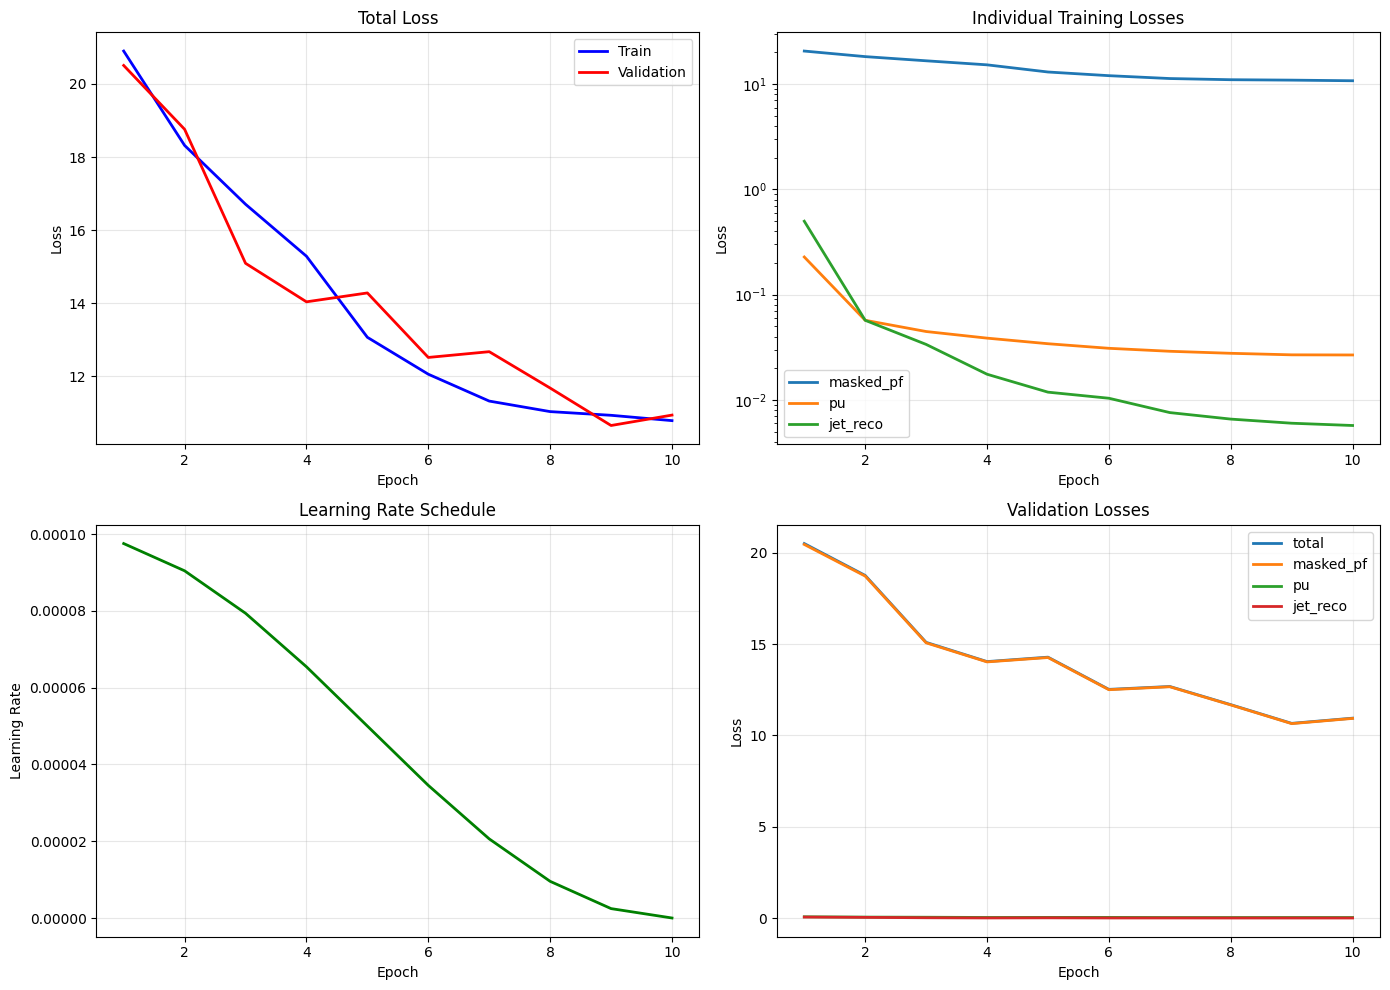


EVALUATING MODEL


Evaluating:  78%|███████▊  | 50/64 [00:00<00:00, 75.95it/s]


MODEL EVALUATION RESULTS

PF Reconstruction:
  MSE: 10.766026 ± 4.156251

Jet Reconstruction:
  MSE: 0.001390 ± 0.000615

PU Prediction:
  Accuracy: 0.9947
  AUC: 1.0000

VISUALIZING RECONSTRUCTION


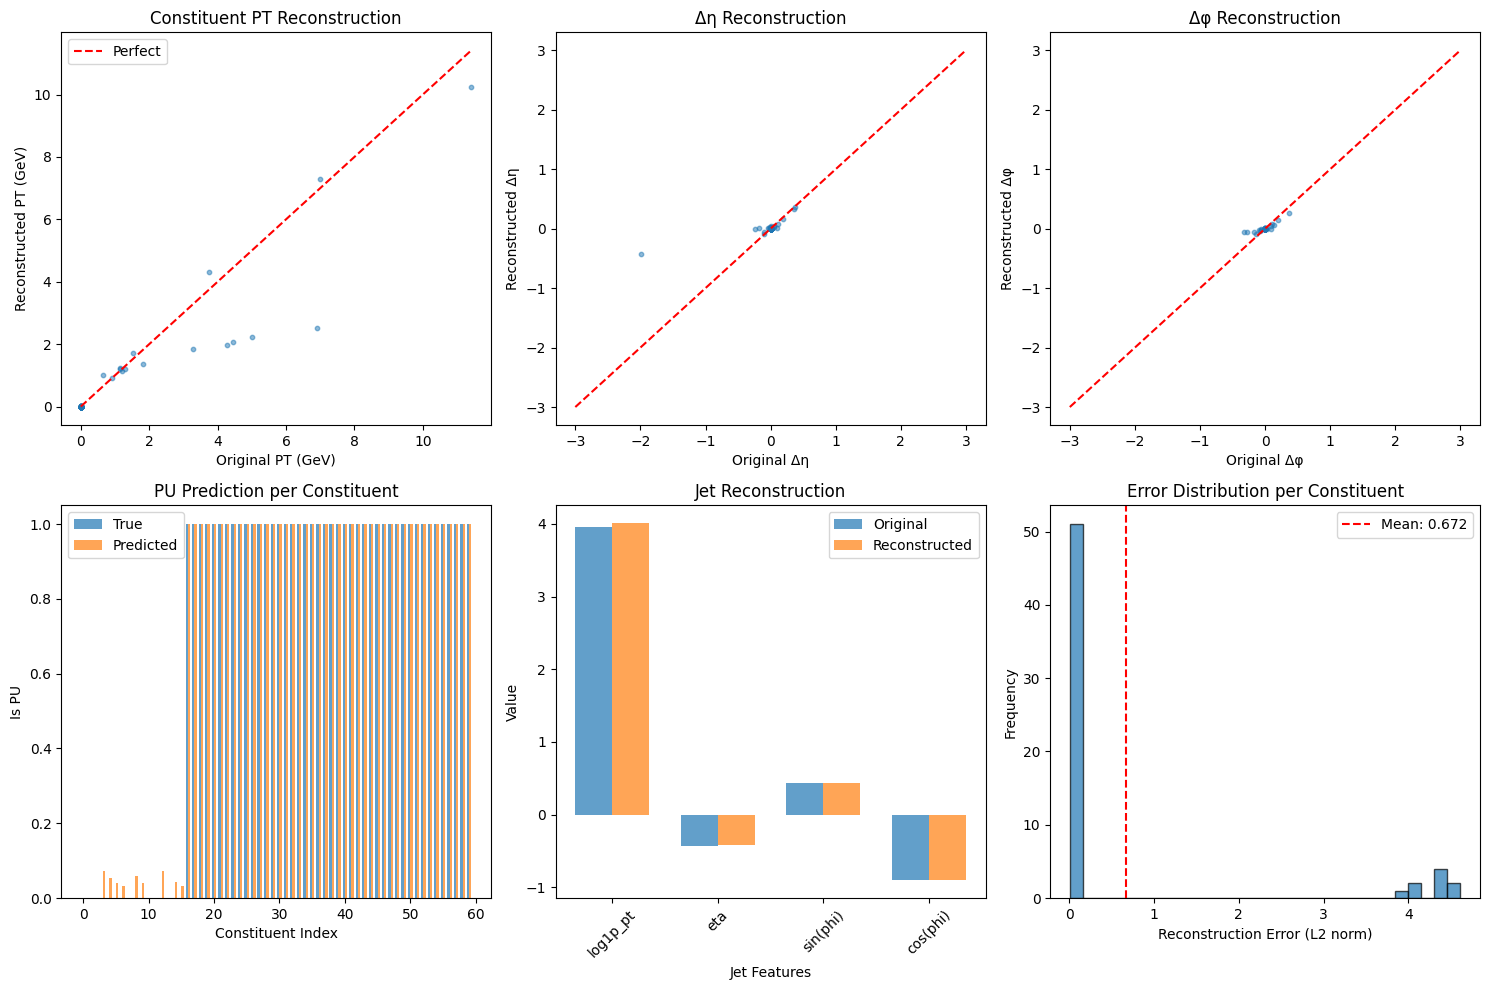


Event 0 Reconstruction Metrics:
  PF MSE: 0.200481
  Jet MSE: 0.000654
  PU Accuracy: 1.0000

Results saved to ./results/


In [13]:
# Split dataset in train/val
from sklearn.model_selection import train_test_split

# Split indices
train_idx, val_idx = train_test_split(range(len(combined)), test_size=0.2, random_state=42)

# Create datasets
train_dataset = torch.utils.data.Subset(dataset, train_idx)
val_dataset = torch.utils.data.Subset(dataset, val_idx)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# Create model
model = JetFoundationModel(
    const_input_dim=14, 
    jet_input_dim=6,
    d_model=128,
    n_latents=64,
    n_heads=8
)

# Run training and evaluation
trained_model, history, results = run_training_and_evaluation(
    model, train_loader, val_loader, 
    epochs=10, device='cuda', save_dir='./results'
)

In [14]:
# Analisi delle scale dei dati
def analyze_data_scale(loader):
    batch = next(iter(loader))
    const = batch['const']
    jet = batch['jet']
    
    print("="*50)
    print("DATA SCALE ANALYSIS")
    print("="*50)
    
    # Constituent features
    print("\nConstituent features:")
    feature_names = [
        'log1p_pt', 'delta_eta', 'delta_phi', 'charge', 'log1p_mass',
        'd0_norm', 'dz_norm', 'log1p_d0_err', 'log1p_dz_err', 'puppiW',
        'is_charged', 'is_pion', 'is_kaon', 'is_proton'
    ]
    
    for i, name in enumerate(feature_names):
        mean_val = const[:, :, i].mean().item()
        std_val = const[:, :, i].std().item()
        min_val = const[:, :, i].min().item()
        max_val = const[:, :, i].max().item()
        
        if abs(mean_val) > 1e6 or abs(std_val) > 1e6:
            print(f"  {name}: mean={mean_val:.2e}, std={std_val:.2e}, min={min_val:.2e}, max={max_val:.2e} ⚠️ SCALA ENORME!")
        else:
            print(f"  {name}: mean={mean_val:.4f}, std={std_val:.4f}, range=[{min_val:.4f}, {max_val:.4f}]")
    
    # Jet features
    print("\nJet features:")
    jet_names = ['log1p_pt', 'eta', 'sin(phi)', 'cos(phi)', 'log1p_mass', 'charge']
    for i, name in enumerate(jet_names):
        mean_val = jet[:, i].mean().item()
        std_val = jet[:, i].std().item()
        min_val = jet[:, i].min().item()
        max_val = jet[:, i].max().item()
        
        if abs(mean_val) > 1e6 or abs(std_val) > 1e6:
            print(f"  {name}: mean={mean_val:.2e}, std={std_val:.2e} ⚠️ SCALA ENORME!")
        else:
            print(f"  {name}: mean={mean_val:.4f}, std={std_val:.4f}, range=[{min_val:.4f}, {max_val:.4f}]")
    
    # Verifica se i dati sono in MeV
    pt_original = np.expm1(const[0, :, 0].cpu().numpy())
    print(f"\nPT originale (primo costituente, primo evento): {pt_original[0]:.2f} GeV")
    if pt_original[0] > 1000:
        print("⚠️ ALERT: PT > 1000 GeV! I dati potrebbero essere in MeV?")
    
    return const, jet

analyze_data_scale(loader)

DATA SCALE ANALYSIS

Constituent features:
  log1p_pt: mean=0.4141, std=0.7658, range=[0.0000, 5.5430]
  delta_eta: mean=-0.0067, std=0.1659, range=[-2.4219, 3.1191]
  delta_phi: mean=-0.0007, std=0.0998, range=[-0.3828, 0.3945]
  charge: mean=-0.0005, std=0.3934, range=[-1.0000, 1.0000]
  log1p_mass: mean=0.0315, std=0.0969, range=[0.0000, 0.6621]
  d0_norm: mean=0.0312, std=1.3613, range=[-22.5636, 38.7790]
  dz_norm: mean=-0.7796, std=20.2513, range=[-106.6436, 93.4888]
  log1p_d0_err: mean=0.0000, std=0.0000, range=[0.0000, 0.0000]
  log1p_dz_err: mean=0.0000, std=0.0000, range=[0.0000, 0.0000]
  puppiW: mean=0.3365, std=0.4726, range=[0.0000, 1.0000]
  is_charged: mean=0.1547, std=0.3617, range=[0.0000, 1.0000]
  is_pion: mean=0.1250, std=0.3308, range=[0.0000, 1.0000]
  is_kaon: mean=0.0172, std=0.1300, range=[0.0000, 1.0000]
  is_proton: mean=0.0125, std=0.1111, range=[0.0000, 1.0000]

Jet features:
  log1p_pt: mean=4.5244, std=0.6246, range=[3.9336, 6.5820]
  eta: mean=-0.8071,

(tensor([[[ 0.8672,  0.2734,  0.2734,  ...,  1.0000,  0.0000,  0.0000],
          [ 0.8853,  0.3906, -0.0684,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.3723,  0.2715,  0.2773,  ...,  0.0000,  0.0000,  0.0000],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[ 1.0996, -0.2141,  0.3027,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.8516, -0.0071,  0.3574,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.3970, -1.7217, -0.2715,  ...,  1.0000,  0.0000,  0.0000],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[ 0.5366,  0.3945, -0.0469,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.3428,  0.3691,